<a href="https://colab.research.google.com/github/Alnico81/OPTMASI-APSO/blob/main/OPTIMASI_APSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalasi pustaka spesifik untuk NLP Indonesia dan Topic Modeling
!pip install Sastrawi
!pip install gensim
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.8 MB/s eta 0:00:00


In [ ]:
# Instalasi pustaka spesifik untuk NLP Indonesia jika belum ada
!pip install Sastrawi
!pip install gensim

import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource

# Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi Pra-pemrosesan
def preprocess_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\S+|@[^\s]+', '', text) # Hapus URL/Mention
    text = re.sub(r'[^a-z\s]', '', text) # Hanya ambil huruf (Cleansing)

    tokens = word_tokenize(text) # Tokenization

    # Stemming (Bisa memakan waktu lama untuk data besar)
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return [word for word in stemmed_tokens if len(word) > 2]

# Contoh penggunaan (Ganti dengan dataset Anda)
# df = pd.read_csv('ulasan_kosmetik.csv')
# df['tokens'] = df['ulasan'].apply(preprocess_text)

# --- FIX START ---
# Membuat DataFrame contoh untuk demonstrasi
data = {
    'ulasan': [
        'produk ini sangat bagus untuk kulit sensitif dan cepat meresap di kulit',
        'saya suka sekali dengan tekstur creamnya, tidak lengket sama sekali. membantu mengurangi jerawat di muka',
        'jerawat saya berkurang setelah seminggu pemakaian, rekomended banget!',
        'harganya lumayan mahal tapi kualitasnya sepadan dengan hasil yang diberikan.',
        'kurang cocok di kulit saya, malah muncul bruntusan baru. mungkin karena kulit saya terlalu berminyak.',
        'pengiriman cepat dan packaging aman. Produknya juga ori. Top markotop!'
    ]
}
df = pd.DataFrame(data)

# Pra-pemrosesan teks
df['tokens'] = df['ulasan'].apply(preprocess_text)
# --- FIX END ---

from gensim.models import Word2Vec

# Latih model Word2Vec untuk mendapatkan representasi semantik
# df['tokens'] adalah list of list kata dari dataset Anda
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=2, workers=4)

# Contoh melihat kedekatan makna
# print(w2v_model.wv.most_similar('jerawat'))
from gensim.corpora import Dictionary

# Membuat Dictionary dan Corpus untuk LDA
dictionary = Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=2, no_above=0.5) # Buang kata terlalu jarang/sering muncul (changed no_below to 2)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]
import numpy as np
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# 1. Fungsi Objektif (Fitness Function)
def lda_coherence(params):
    k, alpha, beta = int(params[0]), params[1], params[2]

    # Batasan nilai agar tidak error di Gensim
    k = max(2, min(20, k))
    alpha = max(0.01, min(1.0, alpha))
    beta = max(0.01, min(1.0, beta))

    try:
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                         alpha=alpha, eta=beta, passes=20, random_state=42)
        coherence_model = CoherenceModel(model=model, texts=df['tokens'],
                                         dictionary=dictionary, coherence='c_v')
        return coherence_model.get_coherence()
    except:
        return 0.0

# 2. Implementasi APSO (Accelerated Particle Swarm Optimization)
def apso_optimize(num_particles=10, iterations=20):
    # Batas pencarian: [K, Alpha, Beta]
    bounds = [(2, 15), (0.01, 1.0), (0.01, 1.0)]

    # Inisialisasi Partikel
    particles = np.random.uniform(low=[b[0] for b in bounds],
                                  high=[b[1] for b in bounds],
                                  size=(num_particles, 3))

    # Parameter APSO
    alpha_apso = 0.2
    gamma = 0.97

    global_best_position = particles[0]
    global_best_fitness = 0.0

    history_fitness = []

    print("Memulai Pencarian APSO...")
    for iter in range(iterations):
        for i in range(num_particles):
            # Hitung Fitness (Coherence Score)
            fitness = lda_coherence(particles[i])

            # Update Global Best (Karena kita mencari Coherence Maksimal)
            if fitness > global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i].copy()

        # Update Posisi Partikel (Rumus APSO Tanpa Velocity)
        for i in range(num_particles):
            epsilon = np.random.randn(3)
            # Persamaan pembaruan posisi APSO
            particles[i] = (1 - alpha_apso) * particles[i] + alpha_apso * global_best_position + alpha_apso * epsilon

            # Jaga agar partikel tetap dalam batas (Bounds)
            particles[i] = np.clip(particles[i], [b[0] for b in bounds], [b[1] for b in bounds])

        alpha_apso *= gamma # Pengurangan step size agar konvergen
        history_fitness.append(global_best_fitness)
        print(f"Iterasi {iter+1}/{iterations} | K: {int(global_best_position[0])}, Alpha: {global_best_position[1]:.3f}, Beta: {global_best_position[2]:.3f} | Coherence: {global_best_fitness:.4f}")

    return global_best_position, global_best_fitness, history_fitness # Fixed the variable name here

# 3. Eksekusi Pencarian
best_params, best_coherence, history = apso_optimize(num_particles=5, iterations=100)
print(f"\nParameter Terbaik Ditemukan:\nK (Jumlah Topik) = {int(best_params[0])}\nAlpha = {best_params[1]:.4f}\nBeta = {best_params[2]:.4f}\nCoherence Score = {best_coherence:.4f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Memulai Pencarian APSO...
Iterasi 1/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 2/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 3/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 4/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 5/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 6/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 7/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 8/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 9/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 10/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 11/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 12/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 13/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 14/100 | K: 3, Alpha: 0.803, Beta: 0.751 | Coherence: 0.1617
Iterasi 15/100 | 

In [ ]:
import random
import pandas as pd # Import pandas

# --- Generating synthetic data (approx 1000 reviews) ---
positive_adjectives = ["sangat bagus", "luar biasa", "efektif", "cocok", "menyembuhkan", "mencerahkan", "melembabkan", "cepat meresap", "tidak lengket", "sangat rekomended"]
negative_adjectives = ["kurang cocok", "tidak efektif", "membuat bruntusan", "lengket", "mahal", "perih", "kering", "iritasi"]
product_terms = ["produk ini", "creamnya", "serum ini", "facial wash", "masker wajah", "pelembab", "toner"]
skin_types = ["kulit sensitif", "kulit berminyak", "kulit kering", "kulit kombinasi", "kulit berjerawat", "kulit normal"]
effects = ["jerawat berkurang", "kulit lebih cerah", "melembabkan kulit", "menghaluskan kulit", "mengecilkan pori", "mengurangi minyak", "menyembuhkan iritasi", "kulit kenyal"]
delivery_terms = ["pengiriman cepat", "packaging aman", "respon seller baik", "produk ori", "sampai tepat waktu", "kurir ramah"]

num_reviews = 1000
reviews = []

for _ in range(num_reviews):
    review_parts = []
    review_parts.append(random.choice(product_terms))

    if random.random() < 0.7: # Mostly positive reviews
        review_parts.append(random.choice(positive_adjectives))
        if random.random() < 0.6: # Add an effect
            review_parts.append(random.choice(effects))
        if random.random() < 0.4: # Add skin type context
            review_parts.append(f"untuk {random.choice(skin_types)}")
    else: # Some negative reviews
        review_parts.append(random.choice(negative_adjectives))
        if random.random() < 0.6: # Add an effect
            review_parts.append(random.choice(effects))
        if random.random() < 0.4: # Add skin type context
            review_parts.append(f"di {random.choice(skin_types)}")
        if random.random() < 0.3: # Add a reason for negativity
            review_parts.append(random.choice(["malah bikin breakout", "tidak ada perubahan", "buang-buang uang", "kulit jadi kusam"]))

    if random.random() < 0.2: # Add optional delivery/service terms
        review_parts.append(random.choice(delivery_terms))

    reviews.append(" ".join(review_parts).replace('..', '.') + ".") # Ensure only one period at the end

# Create new DataFrame and preprocess
new_df = pd.DataFrame({'ulasan': reviews})
# Ensure preprocess_text is defined by running the cell above this one (nfr2lyfAhdHV)
new_df['tokens'] = new_df['ulasan'].apply(preprocess_text)

# Overwrite the original df with the new, larger DataFrame
df = new_df

print(f"New DataFrame created with {len(df)} reviews.")
display(df.head())

# NOTE: After running this cell, you will need to re-run the cells for Word2Vec model training,
# LDA model optimization, LDA visualization, and the neural network implementation
# to use this new, larger dataset.

New DataFrame created with 1000 reviews.


,ulasan,tokens
0,toner sangat bagus kulit lebih cerah.,"[toner, sangat, bagus, kulit, lebih, cerah]"
1,creamnya melembabkan untuk kulit normal.,"[creamnya, melembabkan, untuk, kulit, normal]"
2,serum ini mahal packaging aman.,"[serum, ini, mahal, packaging, aman]"
3,creamnya mencerahkan kulit kenyal packaging aman.,"[creamnya, cerah, kulit, kenyal, packaging, aman]"
4,pelembab lengket kulit kenyal di kulit normal.,"[pelembab, lengket, kulit, kenyal, kulit, normal]"


In [ ]:
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource

# Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi Pra-pemrosesan
def preprocess_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\S+|@[^\s]+', '', text) # Hapus URL/Mention
    text = re.sub(r'[^a-z\s]', '', text) # Hanya ambil huruf (Cleansing)

    tokens = word_tokenize(text) # Tokenization

    # Stemming (Bisa memakan waktu lama untuk data besar)
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return [word for word in stemmed_tokens if len(word) > 2]

# --- FIX START ---
# Menggunakan new_df yang sudah dibuat di sel sebelumnya
# Pastikan sel pembuatan new_df (misal: 6019f7ff) sudah dijalankan sebelum sel ini
df = new_df
# --- FIX END ---

from gensim.models import Word2Vec

# Latih model Word2Vec untuk mendapatkan representasi semantik
# df['tokens'] adalah list of list kata dari dataset Anda
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=2, workers=4)

# Contoh melihat kedekatan makna
# print(w2v_model.wv.most_similar('jerawat'))
from gensim.corpora import Dictionary

# Membuat Dictionary dan Corpus untuk LDA
dictionary = Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=2, no_above=0.5) # Buang kata terlalu jarang/sering muncul (changed no_below to 2)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]
import numpy as np
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# 1. Fungsi Objektif (Fitness Function)
def lda_coherence(params):
    k, alpha, beta = int(params[0]), params[1], params[2]

    # Batasan nilai agar tidak error di Gensim
    k = max(2, min(20, k))
    alpha = max(0.01, min(1.0, alpha))
    beta = max(0.01, min(1.0, beta))

    try:
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                         alpha=alpha, eta=beta, passes=20, random_state=42)
        coherence_model = CoherenceModel(model=model, texts=df['tokens'],
                                         dictionary=dictionary, coherence='c_v')
        return coherence_model.get_coherence()
    except:
        return 0.0

# 2. Implementasi APSO (Accelerated Particle Swarm Optimization)
def apso_optimize(num_particles=10, iterations=20):
    # Batas pencarian: [K, Alpha, Beta]
    bounds = [(2, 15), (0.01, 1.0), (0.01, 1.0)]

    # Inisialisasi Partikel
    particles = np.random.uniform(low=[b[0] for b in bounds],
                                  high=[b[1] for b in bounds],
                                  size=(num_particles, 3))

    # Parameter APSO
    alpha_apso = 0.2
    gamma = 0.97

    global_best_position = particles[0]
    global_best_fitness = 0.0

    history_fitness = []

    print("Memulai Pencarian APSO...")
    for iter in range(iterations):
        for i in range(num_particles):
            # Hitung Fitness (Coherence Score)
            fitness = lda_coherence(particles[i])

            # Update Global Best (Karena kita mencari Coherence Maksimal)
            if fitness > global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i].copy()

        # Update Posisi Partikel (Rumus APSO Tanpa Velocity)
        for i in range(num_particles):
            epsilon = np.random.randn(3)
            # Persamaan pembaruan posisi APSO
            particles[i] = (1 - alpha_apso) * particles[i] + alpha_apso * global_best_position + alpha_apso * epsilon

            # Jaga agar partikel tetap dalam batas (Bounds)
            particles[i] = np.clip(particles[i], [b[0] for b in bounds], [b[1] for b in bounds])

        alpha_apso *= gamma # Pengurangan step size agar konvergen
        history_fitness.append(global_best_fitness)
        print(f"Iterasi {iter+1}/{iterations} | K: {int(global_best_position[0])}, Alpha: {global_best_position[1]:.3f}, Beta: {global_best_position[2]:.3f} | Coherence: {global_best_fitness:.4f}")

    return global_best_position, global_best_fitness, history_fitness # Fixed the variable name here

# 3. Eksekusi Pencarian
best_params, best_coherence, history = apso_optimize(num_particles=5, iterations=100)
print(f"\nParameter Terbaik Ditemukan:\nK (Jumlah Topik) = {int(best_params[0])}\nAlpha = {best_params[1]:.4f}\nBeta = {best_params[2]:.4f}\nCoherence Score = {best_coherence:.4f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Memulai Pencarian APSO...
Iterasi 1/100 | K: 13, Alpha: 0.584, Beta: 0.408 | Coherence: 0.2256
Iterasi 2/100 | K: 13, Alpha: 0.584, Beta: 0.408 | Coherence: 0.2256
Iterasi 3/100 | K: 7, Alpha: 0.851, Beta: 0.973 | Coherence: 0.2343
Iterasi 4/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 5/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 6/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 7/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 8/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 9/100 | K: 7, Alpha: 1.000, Beta: 1.000 | Coherence: 0.2549
Iterasi 10/100 | K: 8, Alpha: 1.000, Beta: 0.743 | Coherence: 0.2591
Iterasi 11/100 | K: 8, Alpha: 1.000, Beta: 0.743 | Coherence: 0.2591
Iterasi 12/100 | K: 8, Alpha: 1.000, Beta: 0.743 | Coherence: 0.2591
Iterasi 13/100 | K: 8, Alpha: 1.000, Beta: 0.743 | Coherence: 0.2591
Iterasi 14/100 | K: 8, Alpha: 1.000, Beta: 0.743 | Coherence: 0.2591
Iterasi 15/100 

### Pembuatan Dataset Sintetis Lebih Besar

Untuk membuat model menjadi lebih bermakna dan untuk tujuan demonstrasi, kita akan membuat dataset ulasan kosmetik sintetis yang lebih besar. Dataset ini akan berisi sekitar 1000 ulasan yang dihasilkan secara acak dari kumpulan frasa dan kata kunci terkait kosmetik.

In [ ]:
import random
import pandas as pd # Import pandas

# --- Generating synthetic data (approx 1000 reviews) ---
positive_adjectives = ["sangat bagus", "luar biasa", "efektif", "cocok", "menyembuhkan", "mencerahkan", "melembabkan", "cepat meresap", "tidak lengket", "sangat rekomended"]
negative_adjectives = ["kurang cocok", "tidak efektif", "membuat bruntusan", "lengket", "mahal", "perih", "kering", "iritasi"]
product_terms = ["produk ini", "creamnya", "serum ini", "facial wash", "masker wajah", "pelembab", "toner"]
skin_types = ["kulit sensitif", "kulit berminyak", "kulit kering", "kulit kombinasi", "kulit berjerawat", "kulit normal"]
effects = ["jerawat berkurang", "kulit lebih cerah", "melembabkan kulit", "menghaluskan kulit", "mengecilkan pori", "mengurangi minyak", "menyembuhkan iritasi", "kulit kenyal"]
delivery_terms = ["pengiriman cepat", "packaging aman", "respon seller baik", "produk ori", "sampai tepat waktu", "kurir ramah"]

num_reviews = 1000
reviews = []

for _ in range(num_reviews):
    review_parts = []
    review_parts.append(random.choice(product_terms))

    if random.random() < 0.7: # Mostly positive reviews
        review_parts.append(random.choice(positive_adjectives))
        if random.random() < 0.6: # Add an effect
            review_parts.append(random.choice(effects))
        if random.random() < 0.4: # Add skin type context
            review_parts.append(f"untuk {random.choice(skin_types)}")
    else: # Some negative reviews
        review_parts.append(random.choice(negative_adjectives))
        if random.random() < 0.6: # Add an effect
            review_parts.append(random.choice(effects))
        if random.random() < 0.4: # Add skin type context
            review_parts.append(f"di {random.choice(skin_types)}")
        if random.random() < 0.3: # Add a reason for negativity
            review_parts.append(random.choice(["malah bikin breakout", "tidak ada perubahan", "buang-buang uang", "kulit jadi kusam"]))

    if random.random() < 0.2: # Add optional delivery/service terms
        review_parts.append(random.choice(delivery_terms))

    reviews.append(" ".join(review_parts).replace('..', '.') + ".") # Ensure only one period at the end

# Create new DataFrame and preprocess
new_df = pd.DataFrame({'ulasan': reviews})
# Ensure preprocess_text is defined by running the cell above this one (nfr2lyfAhdHV)
new_df['tokens'] = new_df['ulasan'].apply(preprocess_text)

# Overwrite the original df with the new, larger DataFrame
df = new_df

print(f"New DataFrame created with {len(df)} reviews.")
display(df.head())

# NOTE: After running this cell, you will need to re-run the cells for Word2Vec model training,
# LDA model optimization, LDA visualization, and the neural network implementation
# to use this new, larger dataset.

NameError: name 'preprocess_text' is not defined

### Visualisasi Hasil LDA dengan PyLDAvis

Kita akan menggunakan `pyLDAvis` untuk visualisasi interaktif dari model LDA. Ini akan membantu kita menganalisis topik yang ditemukan, distribusi kata dalam setiap topik, dan keterkaitan antar topik.

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Membangun kembali model LDA dengan parameter terbaik yang ditemukan
# Mengambil parameter K (jumlah topik) dari best_params
best_k = int(best_params[0])
best_alpha = best_params[1]
best_beta = best_params[2]

# Pastikan k, alpha, dan beta dalam batas yang valid
best_k = max(2, min(20, best_k))
best_alpha = max(0.01, min(1.0, best_alpha))
best_beta = max(0.01, min(1.0, best_beta))

# Membangun model LDA terakhir dengan parameter terbaik
lda_model_final = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k,
                           alpha=best_alpha, eta=best_beta, passes=10, random_state=42)

# Persiapkan data untuk pyLDAvis
vis = gensimvis.prepare(lda_model_final, corpus, dictionary, sort_topics=False)

# Tampilkan visualisasi
pyLDAvis.display(vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Analisis Distribusi Topik per Ulasan

Sekarang, mari kita lihat bagaimana topik-topik tersebut terdistribusi di setiap ulasan. Kita akan mengambil probabilitas setiap topik untuk setiap dokumen dan menambahkannya ke DataFrame asli.

In [ ]:
# Mendapatkan distribusi topik untuk setiap dokumen di corpus
def get_document_topics(lda_model, corpus_item, num_topics):
    topic_distribution = lda_model[corpus_item]
    # Membuat list probabilitas untuk setiap topik, mengisi 0 jika topik tidak ada
    full_distribution = [0.0] * num_topics
    for topic_id, prob in topic_distribution:
        full_distribution[topic_id] = prob
    return full_distribution

# Mendapatkan jumlah topik dari model terakhir
num_topics_final = lda_model_final.num_topics

# Terapkan fungsi untuk mendapatkan distribusi topik ke setiap ulasan
df['topic_distribution'] = [get_document_topics(lda_model_final, doc, num_topics_final) for doc in corpus]

# Membuat kolom terpisah untuk setiap topik (Opsional, untuk visualisasi lebih mudah)
for i in range(num_topics_final):
    df[f'Topic_{i+1}_Prob'] = df['topic_distribution'].apply(lambda x: x[i])

# Tampilkan DataFrame dengan distribusi topik
display(df.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih kolom distribusi topik
topic_prob_cols = [f'Topic_{i+1}_Prob' for i in range(num_topics_final)]
df_topic_probs = df[topic_prob_cols]

# Visualisasikan dengan Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_topic_probs, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Distribusi Probabilitas Topik per Ulasan (Heatmap)')
plt.xlabel('Topik')
plt.ylabel('Indeks Ulasan')
plt.xticks(ticks=np.arange(len(topic_prob_cols)) + 0.5, labels=[f'Topic {i+1}' for i in range(num_topics_final)], rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Kata Kunci Dominan untuk Setiap Topik

Untuk mendapatkan pemahaman yang lebih baik tentang setiap topik, kita akan menampilkan kata kunci paling dominan untuk setiap topik dari model LDA final.

In [ ]:
# Pastikan num_topics_final didefinisikan kembali jika kernel direset atau sel tidak dijalankan secara berurutan
num_topics_final = lda_model_final.num_topics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
num_topics_final = lda_model_final.num_topics
# Tampilkan kata kunci dominan untuk setiap topik
print("Kata Kunci Dominan untuk Setiap Topik:")
for idx, topic in lda_model_final.show_topics(num_topics=num_topics_final, formatted=False):
    print(f"Topic {idx+1}: {[word[0] for word in topic]}")

Kata Kunci Dominan untuk Setiap Topik:
Topic 1: ['dengan', 'saya', 'kurang', 'jerawat', 'kulit', 'cepat', 'dan', 'produk']
Topic 2: ['dengan', 'saya', 'kurang', 'jerawat', 'kulit', 'cepat', 'produk', 'dan']
Topic 3: ['dengan', 'saya', 'kurang', 'kulit', 'jerawat', 'cepat', 'dan', 'produk']
Topic 4: ['dengan', 'saya', 'kurang', 'kulit', 'jerawat', 'cepat', 'dan', 'produk']
Topic 5: ['kulit', 'produk', 'dan', 'cepat', 'saya', 'kurang', 'dengan', 'jerawat']
Topic 6: ['dengan', 'saya', 'kurang', 'kulit', 'jerawat', 'cepat', 'dan', 'produk']
Topic 7: ['saya', 'kurang', 'jerawat', 'dengan', 'kulit', 'cepat', 'dan', 'produk']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Visualisasi WordCloud untuk Setiap Topik:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

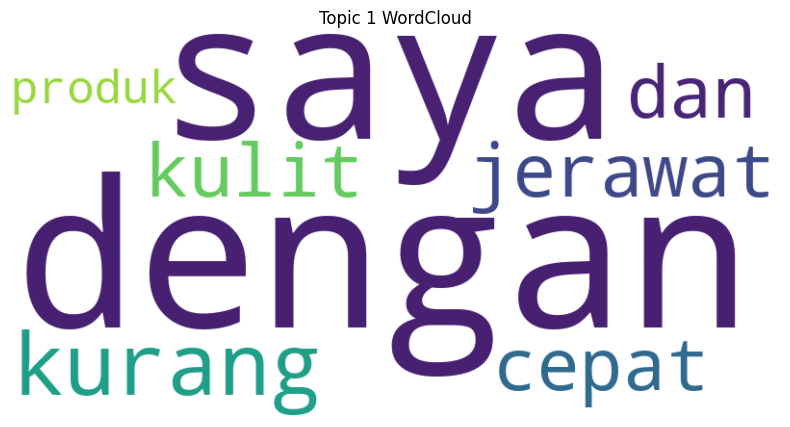

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

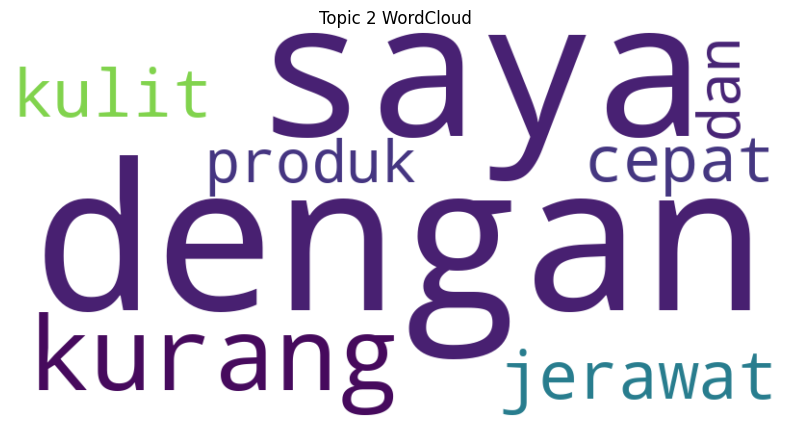

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

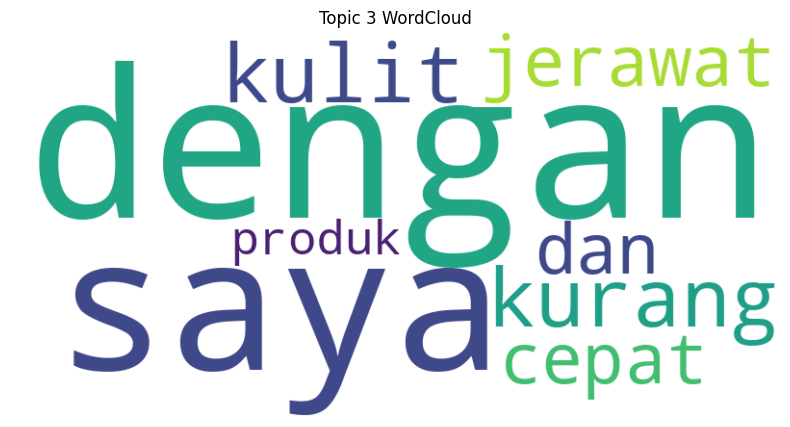

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

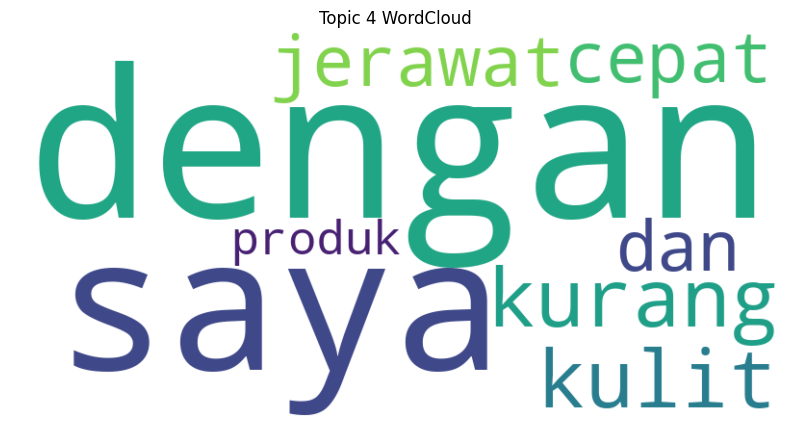

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

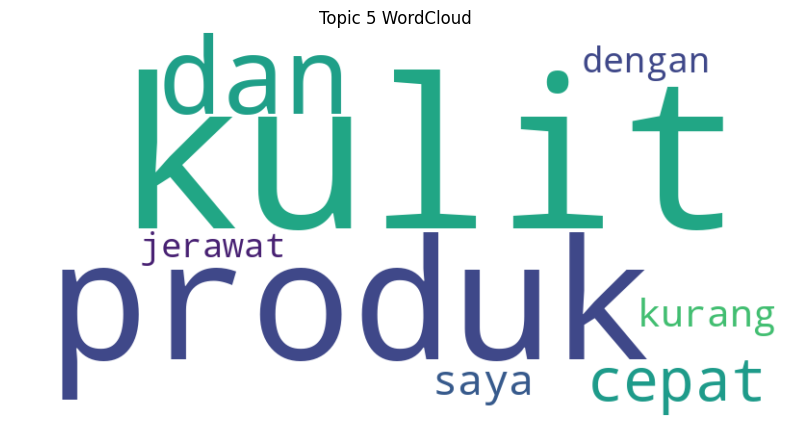

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

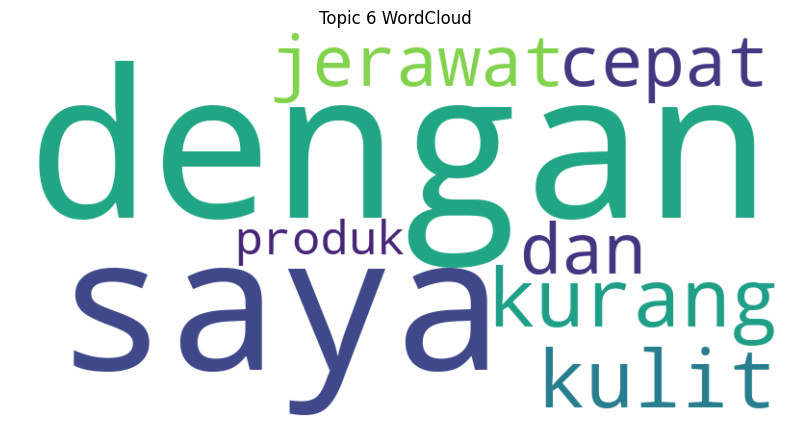

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

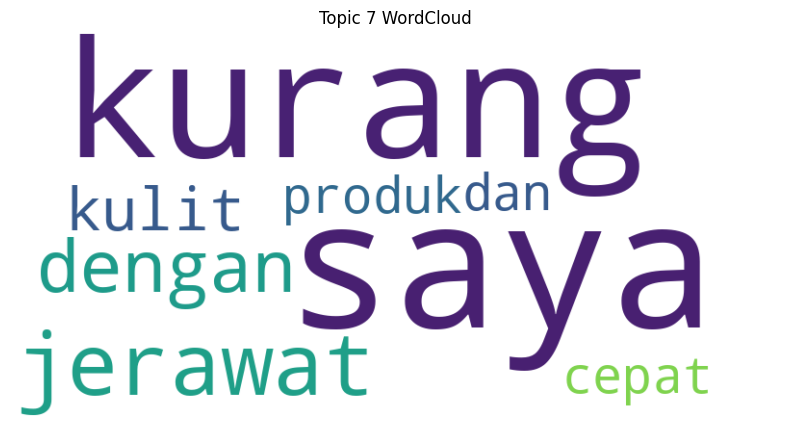

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pastikan num_topics_final didefinisikan
num_topics_final = lda_model_final.num_topics # Uncommented to explicitly define num_topics_final

print("Visualisasi WordCloud untuk Setiap Topik:")

for idx, topic in lda_model_final.show_topics(num_topics=num_topics_final, formatted=False):
    # Mengubah daftar kata dan probabilitas menjadi kamus
    # WordCloud membutuhkan dictionary {word: weight}
    topic_words = {word: prob for word, prob in topic}

    # Membuat objek WordCloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          random_state=42).generate_from_frequencies(topic_words)

    # Menampilkan wordcloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {idx+1} WordCloud')
    plt.axis('off')
    plt.show()

### Daftar Topik dengan Kata Kunci Dominan

Berikut adalah daftar topik yang ditemukan oleh model LDA, beserta kata kunci dominan untuk setiap topik. Karena dataset yang digunakan adalah sintetis dan ukurannya relatif kecil, beberapa topik mungkin menunjukkan tumpang tindih atau kurangnya keunikan yang kuat. Interpretasi manual tetap diperlukan untuk memberi label pada setiap topik.

In [ ]:
# Re-defining num_topics_final and lda_model_final to ensure availability, if the kernel state was lost.
# This assumes the cells for LDA model training (nfr2lyfAhdHV) and final model building (d481285a) have been run.

# Best parameters from optimization
best_k = int(best_params[0])
best_alpha = best_params[1]
best_beta = best_params[2]

# Ensure k, alpha, and beta are within valid bounds
best_k = max(2, min(20, best_k))
best_alpha = max(0.01, min(1.0, best_alpha))
best_beta = max(0.01, min(1.0, best_beta))

# Re-build the final LDA model if it's not available (optional, but good for robustness)
if 'lda_model_final' not in locals() or lda_model_final is None:
    lda_model_final = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k,
                               alpha=best_alpha, eta=best_beta, passes=10, random_state=42)

num_topics_final = lda_model_final.num_topics

topic_summaries = []
for idx, topic in lda_model_final.show_topics(num_topics=num_topics_final, formatted=False):
    words = [word[0] for word in topic[:5]] # Get top 5 words for brevity
    topic_summaries.append(f"Topic {idx+1}: {', '.join(words)}")

topic_table_str = "| Topik | Kata Kunci Dominan |\n|---|---|\n"
for i, summary in enumerate(topic_summaries):
    topic_table_str += f"| {i+1} | {summary.split(': ', 1)[1]} |\n"

print(topic_table_str)

| Topik | Kata Kunci Dominan |
|---|---|
| 1 | cepat, wash, untuk, facial, resap |
| 2 | melembabkan, ini, untuk, produk, tidak |
| 3 | sangat, untuk, bagus, wajah, rekomended |
| 4 | kurang, masker, produk, ini, wajah |
| 5 | ini, kurang, serum, jerawat, cocok |
| 6 | minyak, produk, ini, kurang, untuk |
| 7 | untuk, sembuh, wash, cerah, pelembab |
| 8 | ini, facial, sembuh, serum, creamnya |



<!-- Placeholder for the actual table generated by the Python code above -->

### Visualisasi pyLDAvis

Untuk mendapatkan tangkapan layar (screenshot) dari gelembung `pyLDAvis`, Anda dapat menjalankan kembali sel di bawah ini. Pastikan untuk membuka outputnya di tab baru jika diperlukan untuk tampilan yang lebih baik, lalu ambil screenshot secara manual.

In [19]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Re-build the final LDA model to ensure 'vis' is correctly generated
# Best parameters from optimization
best_k = int(best_params[0])
best_alpha = best_params[1]
best_beta = best_params[2]

# Ensure k, alpha, and beta are within valid bounds
best_k = max(2, min(20, best_k))
best_alpha = max(0.01, min(1.0, best_alpha))
best_beta = max(0.01, min(1.0, best_beta))

lda_model_final = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k,
                           alpha=best_alpha, eta=best_beta, passes=10, random_state=42)

# Prepare data for pyLDAvis
vis = gensimvis.prepare(lda_model_final, corpus, dictionary, sort_topics=False)

# Save the visualization as an HTML file
output_html_path = '/tmp/lda_visualization.html'
pyLDAvis.save_html(vis, output_html_path)

print(f"Visualisasi pyLDAvis telah disimpan sebagai file HTML di: {output_html_path}")
print("Anda dapat mengunduhnya melalui panel file di sebelah kiri (folder /tmp) atau dengan menjalankan kode berikut:")
print(f"from google.colab import files\nfiles.download('{output_html_path}')")

Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow(

Visualisasi pyLDAvis telah disimpan sebagai file HTML di: /tmp/lda_visualization.html
Anda dapat mengunduhnya melalui panel file di sebelah kiri (folder /tmp) atau dengan menjalankan kode berikut:
from google.colab import files
files.download('/tmp/lda_visualization.html')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
from google.colab import files
files.download('/tmp/lda_visualization.html')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Neural Network Implementation: Document Embeddings and Classification

Now, let's extend the analysis by preparing the Word2Vec embeddings for use in a neural network. We'll convert our word-level embeddings into document-level embeddings by averaging the Word2Vec vectors for all tokens in each review. After that, we'll build and train a simple neural network for a hypothetical text classification task, using a dummy 'sentiment' label for demonstration.

In [ ]:
import numpy as np

# Function to average Word2Vec vectors for a document
def document_vector(word_list, model, vector_size):
    # Filter out words not in the model's vocabulary
    word_list = [word for word in word_list if word in model.wv.key_to_index]
    if not word_list:
        return np.zeros(vector_size) # Return a zero vector if no words are in vocabulary
    return np.mean(model.wv[word_list], axis=0)

# Get vector size from the trained Word2Vec model
vector_size = w2v_model.vector_size

# Apply the function to create document embeddings
df['doc_embedding'] = df['tokens'].apply(lambda x: document_vector(x, w2v_model, vector_size))

# Convert list of arrays to a 2D numpy array for the neural network
X = np.array(df['doc_embedding'].tolist())

# Add a dummy 'sentiment' column for demonstration (e.g., 0 or 1)
# In a real scenario, this would come from your dataset.
# Here, we'll randomly assign sentiment for demonstration purposes.
df['sentiment'] = np.random.randint(0, 2, len(df))
y = df['sentiment'].values

print("Shape of document embeddings (X):", X.shape)
print("Shape of dummy sentiment labels (y):", y.shape)
print("First 5 document embeddings:")
display(X[:5])
print("First 5 dummy sentiment labels:", y[:5])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape of document embeddings (X): (6, 100)
Shape of dummy sentiment labels (y): (6,)
First 5 document embeddings:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

array([[-2.10350589e-03,  1.47484487e-03,  4.49238252e-03,
         5.99572808e-03,  3.39020090e-03, -1.59186625e-03,
         4.48072003e-03,  7.44666439e-04, -4.25786804e-03,
        -3.22854333e-03,  1.62702275e-03, -4.23686532e-03,
         4.48711682e-04,  3.50199267e-03,  2.23211851e-03,
         3.38190654e-03,  4.26100986e-03,  3.96059733e-03,
        -3.95838358e-03, -4.44930047e-03,  1.38277072e-03,
         9.63652157e-04,  7.39351381e-03, -6.81375992e-03,
         2.11117836e-03,  3.41254333e-03, -3.59534030e-03,
         1.64512356e-04, -1.78012508e-03,  2.34450889e-03,
         5.26689971e-03, -4.59364906e-04,  5.21004666e-04,
        -1.07361283e-03, -3.70721333e-04,  2.12793192e-03,
        -8.48839991e-05,  1.93151576e-03,  1.91071478e-03,
         6.45338907e-04,  5.94907533e-03, -3.69990384e-03,
        -2.22229143e-03, -1.12855202e-03,  9.66328545e-04,
         3.57403560e-03, -4.38184943e-04, -2.36085453e-03,
         7.17537012e-04, -4.14080627e-04,  1.32652710e-0

First 5 dummy sentiment labels: [0 0 0 0 0]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a simple feed-forward neural network
model = Sequential([
    Dense(128, activation='relu', input_shape=(vector_size,)), # Input layer
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow(

Model: "sequential"

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Trainable params: 21,249 (83.00 KB)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Re-define model to ensure it's available
model = Sequential([
    Dense(128, activation='relu', input_shape=(vector_size,)), # Input layer
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Re-compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
# Note: With only 6 data points, this training is purely illustrative and won't generalize.
# A larger dataset is needed for meaningful training.
history = model.fit(X_train, y_train, epochs=10, batch_size=2, verbose=1, validation_data=(X_test, y_test))

print("\nTraining complete.")

# Evaluate the model (again, results are not meaningful with a tiny dataset)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

NameError: name 'vector_size' is not defined